# MoE 2x1 — Real Data Evaluation

Evaluate the best MoE 2×1 model (bandwidth=4.0, variance-optimal gating) on
real convertible bond market data from `real_cb_raw.csv`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[0]
sys.path.append(str(PROJECT_ROOT))

In [2]:
import numpy as np
import pandas as pd
import torch
import pickle
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

from preprocessing.feature_engineering import engineer_features
from architectures.moe_pricer import MoEPricer

SEED = 42
N_SAMPLES = 1_000
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Load & Prepare Real Data

Load `real_cb_raw.csv`, sample 1,000 observations, convert units, and engineer
the same 24 features used during training.

In [3]:
raw = pd.read_csv("../real_cb_raw.csv")
print(f"Total rows: {len(raw):,}")

sample = raw.sample(n=N_SAMPLES, random_state=SEED).copy()

# Unit conversions
sample["r"] = sample["r_pct"] / 100
sample["q"] = sample["q_pct"] / 100
sample["bs_vol"] = sample["sigma_pct"] / 100
sample["credit_spread"] = sample["credit_spread_bps"] / 10_000
sample["maturity_years"] = sample["maturity"]  # already in years
sample["price_convertible"] = sample["price"]
sample["frequency"] = 2  # semiannual (standard for US convertibles)

# Real data has CR per $1000 bond; training data uses CR per $100 face.
# Evidence: real CP = 1000/CR (e.g. 1000/28.6 ~ 34.95), training CP = 100/CR.
sample["conversion_ratio"] = sample["conversion_ratio"] / 10
sample["conversion_price"] = sample["redemption"] / sample["conversion_ratio"]

# Feature engineering (all 3 tiers)
df = engineer_features(sample, tiers=[1, 2, 3])

# Feature order must match training
feature_cols = [
    "S", "r", "q", "bs_vol", "credit_spread", "coupon_rate", "frequency",
    "maturity_years", "conversion_ratio", "conversion_price",
    "log_moneyness", "total_vol", "income_advantage", "risky_discount_rate",
    "conversion_premium", "spread_to_vol_ratio", "sqrt_maturity", "parity",
    "total_remaining_income", "real_rate", "credit_vol_product",
    "income_to_optionality", "rate_spread_ratio", "frequency_per_year",
]

X = df[feature_cols]
y_true_price = df["price_convertible"].values

print(f"Feature matrix: {X.shape}")
print(f"Price range: ${y_true_price.min():.2f} – ${y_true_price.max():.2f}")
print(f"\nComplexity flags:")
print(sample["complexity_flags"].fillna("VANILLA").value_counts().to_string())

Total rows: 137,157
Feature matrix: (1000, 24)
Price range: $22.50 – $119.68

Complexity flags:
complexity_flags
COCO                                     398
VANILLA                                  349
COCO,CONVERT_ON_CALL                      84
CALLABLE                                  79
CALLABLE,COCO                             26
PUTABLE,CALLABLE,COCO,CONVERT_ON_CALL     15
CONVERT_ON_CALL                           11
CALLABLE,COCO,CONVERT_ON_CALL              9
PUTABLE                                    8
PUTABLE,COCO                               8
PUTABLE,CALLABLE,COCO                      5
PUTABLE,CALLABLE,CONVERT_ON_CALL           5
PUTABLE,CALLABLE                           2
PERCS                                      1


## Feature Distribution Comparison

Compare converted real data feature ranges to training data ranges.
Highlights where the real data falls outside the training distribution.

In [4]:
train_df = pd.read_csv("../data/vanilla_convertibles_data_enhanced.csv")

compare_cols = ["S", "r", "q", "bs_vol", "credit_spread", "coupon_rate",
                "maturity_years", "conversion_ratio", "conversion_price"]

print(f"{'Feature':<20} {'Train [min, max]':>28} {'Real [min, max]':>28} {'OOD%':>8}")
print("-" * 88)
for col in compare_cols:
    t_min, t_max = train_df[col].min(), train_df[col].max()
    r_min, r_max = df[col].min(), df[col].max()
    # % of real data outside training range
    ood = ((df[col] < t_min) | (df[col] > t_max)).mean() * 100
    flag = " <<<" if ood > 5 else ""
    print(f"{col:<20} [{t_min:>10.4f}, {t_max:>10.4f}]   [{r_min:>10.4f}, {r_max:>10.4f}]   {ood:>6.1f}%{flag}")

print("\n(<<< = >5% of real samples outside training range)")

Feature                          Train [min, max]              Real [min, max]     OOD%
----------------------------------------------------------------------------------------
S                    [   10.0005,   499.9994]   [    0.2601,   457.7800]     24.1% <<<
r                    [    0.0100,     0.0900]   [    0.0000,     0.0551]     27.7% <<<
q                    [    0.0000,     0.0600]   [    0.0000,     0.3000]     84.2% <<<
bs_vol               [    0.1000,     0.8000]   [    0.1018,     3.7735]     19.0% <<<
credit_spread        [    0.0050,     0.1500]   [    0.0001,     0.4599]     12.5% <<<
coupon_rate          [    0.0000,     0.1000]   [    0.0000,     0.0950]      5.0%
maturity_years       [    1.0000,    10.0000]   [    0.0849,    51.8001]     20.6% <<<
conversion_ratio     [    1.0000,    10.0000]   [    0.1141,    74.0741]     28.5% <<<
conversion_price     [   10.0000,    99.9994]   [    2.7000,   876.5548]     28.5% <<<

(<<< = >5% of real samples outside training

## Load Model & Run Inference

Load the best MoE 2×1 model (bw=4.0) and scalers, then predict on the real sample.

In [5]:
with open("../models/scaler_X.pkl", "rb") as f:
    scaler_X = pickle.load(f)
with open("../models/scaler_y.pkl", "rb") as f:
    scaler_y = pickle.load(f)

pricer = MoEPricer.load("../models/moe_2x1_var_bw4.0.pt", device=device)
pricer.expert_pool.eval()

print("Model and scalers loaded.")

Model and scalers loaded.


In [6]:
X_raw = torch.tensor(X.values, dtype=torch.float32).to(device)
X_scaled = torch.tensor(scaler_X.transform(X), dtype=torch.float32).to(device)

with torch.no_grad():
    m_bins, t_bins = pricer.gating.route(X_raw)
    preds_sc = pricer.expert_pool.forward_routed(X_scaled, m_bins, t_bins).cpu().numpy()

# Inverse transform: scaler_y -> expm1
preds_norm = scaler_y.inverse_transform(preds_sc).ravel()
preds_price = np.expm1(preds_norm)

print(f"Predictions: {len(preds_price):,} samples")
print(f"Predicted price range: ${preds_price.min():.2f} – ${preds_price.max():.2f}")

Predictions: 1,000 samples
Predicted price range: $20.34 – $1538.41


/opt/homebrew/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(


## Summary Metrics

Overall error statistics comparing model predictions to market prices.

In [7]:
errors = preds_price - y_true_price
abs_errors = np.abs(errors)
pct_errors = abs_errors / np.abs(y_true_price) * 100

mae = abs_errors.mean()
rmse = np.sqrt((errors ** 2).mean())
r2 = r2_score(y_true_price, preds_price)

print(f"{'Metric':<25} {'Value':>12}")
print("-" * 38)
print(f"{'MAE ($)':<25} {mae:>12.2f}")
print(f"{'Median AE ($)':<25} {np.median(abs_errors):>12.2f}")
print(f"{'RMSE ($)':<25} {rmse:>12.2f}")
print(f"{'Mean Error ($)':<25} {errors.mean():>12.2f}")
print(f"{'R²':<25} {r2:>12.6f}")
print(f"{'MAPE (%)':<25} {pct_errors.mean():>12.2f}")
print(f"{'Median APE (%)':<25} {np.median(pct_errors):>12.2f}")
print(f"{'95th pct AE ($)':<25} {np.percentile(abs_errors, 95):>12.2f}")
print(f"{'99th pct AE ($)':<25} {np.percentile(abs_errors, 99):>12.2f}")
print(f"{'Max AE ($)':<25} {abs_errors.max():>12.2f}")
print(f"\n{'Price range (true)':<25} ${y_true_price.min():.2f} – ${y_true_price.max():.2f}")
print(f"{'Price mean (true)':<25} ${y_true_price.mean():.2f}")
print(f"{'Price mean (pred)':<25} ${preds_price.mean():.2f}")

Metric                           Value
--------------------------------------
MAE ($)                          26.47
Median AE ($)                     8.95
RMSE ($)                         92.17
Mean Error ($)                   21.45
R²                          -45.931934
MAPE (%)                         29.74
Median APE (%)                    9.87
95th pct AE ($)                  61.14
99th pct AE ($)                 432.27
Max AE ($)                     1438.20

Price range (true)        $22.50 – $119.68
Price mean (true)         $89.51
Price mean (pred)         $110.96


## Error Breakdown Tables

Price error by regime, maturity, moneyness, credit risk, and complexity flags.

In [8]:
analysis = pd.DataFrame({
    "price_true": y_true_price,
    "price_pred": preds_price,
    "price_err": abs_errors,
    "signed_err": errors,
    "pct_err": pct_errors,
    "maturity_years": df["maturity_years"].values,
    "log_moneyness": df["log_moneyness"].values,
    "credit_spread": df["credit_spread"].values,
    "complexity": df["complexity_flags"].fillna("VANILLA").values,
})

# Price regime buckets (real data range: ~$20–$150)
analysis["price_regime"] = pd.cut(analysis["price_true"],
    bins=[0, 50, 80, 95, 105, 150],
    labels=["< $50", "$50-80", "$80-95", "$95-105", "> $105"])

# Maturity buckets
analysis["maturity"] = pd.cut(analysis["maturity_years"],
    bins=[0, 1, 3, 5, 10, np.inf],
    labels=["< 1y", "1-3y", "3-5y", "5-10y", "> 10y"])

# Moneyness buckets
analysis["moneyness"] = pd.cut(analysis["log_moneyness"],
    bins=[-np.inf, -0.5, 0, 0.5, 1.0, np.inf],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM"])

# Credit risk buckets
analysis["credit_risk"] = pd.cut(analysis["credit_spread"],
    bins=[0, 0.03, 0.06, 0.10, np.inf],
    labels=["Low (<300bp)", "Med (300-600bp)", "High (600-1000bp)", "Very High (>1000bp)"])

print("=== Price Error ($) by Price Regime ===")
regime_stats = analysis.groupby("price_regime", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
    MAPE=("pct_err", "mean"),
).reset_index()
print(regime_stats.to_string(index=False))

print("\n=== Price Error ($) by Maturity ===")
mat_stats = analysis.groupby("maturity", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
    MAPE=("pct_err", "mean"),
).reset_index()
print(mat_stats.to_string(index=False))

print("\n=== Price Error ($) by Moneyness ===")
mon_stats = analysis.groupby("moneyness", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
    MAPE=("pct_err", "mean"),
).reset_index()
print(mon_stats.to_string(index=False))

print("\n=== Price Error ($) by Credit Risk ===")
credit_stats = analysis.groupby("credit_risk", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    RMSE=("price_err", lambda x: np.sqrt((x**2).mean())),
    MAPE=("pct_err", "mean"),
).reset_index()
print(credit_stats.to_string(index=False))

print("\n=== Price Error ($) by Complexity ===")
comp_stats = analysis.groupby("complexity", observed=True).agg(
    count=("price_err", "size"),
    MAE=("price_err", "mean"),
    MedAE=("price_err", "median"),
    MAPE=("pct_err", "mean"),
).sort_values("count", ascending=False)
print(comp_stats.to_string())

=== Price Error ($) by Price Regime ===
price_regime  count       MAE       RMSE      MAPE
       < $50     21 28.772763  41.980933 62.405020
      $50-80    170 24.386944  51.261081 35.395738
      $80-95    368 15.578237  39.220775 17.619624
     $95-105    402 36.569452 135.421286 36.736626
      > $105     39 32.925182  43.072355 29.841603

=== Price Error ($) by Maturity ===
maturity  count       MAE       RMSE      MAPE
    < 1y     97 48.022042 208.063335 47.996938
    1-3y    354 21.618066  79.693610 23.196475
    3-5y    335 26.966642  74.143123 32.228320
   5-10y    105 19.815467  27.190433 22.472906
   > 10y    109 27.912106  34.237293 34.131661

=== Price Error ($) by Moneyness ===
moneyness  count        MAE       RMSE       MAPE
 Deep OTM    685   9.822048  13.661179  12.637616
      OTM    247  18.756329  24.897056  18.749164
      ATM     27  43.811944  48.695216  51.926482
      ITM     17 141.445454 146.353173 181.155562
 Deep ITM     24 479.974617 569.550522 498.9282

## Price Error Analysis

Six-panel diagnostic plots matching the training notebook evaluation.

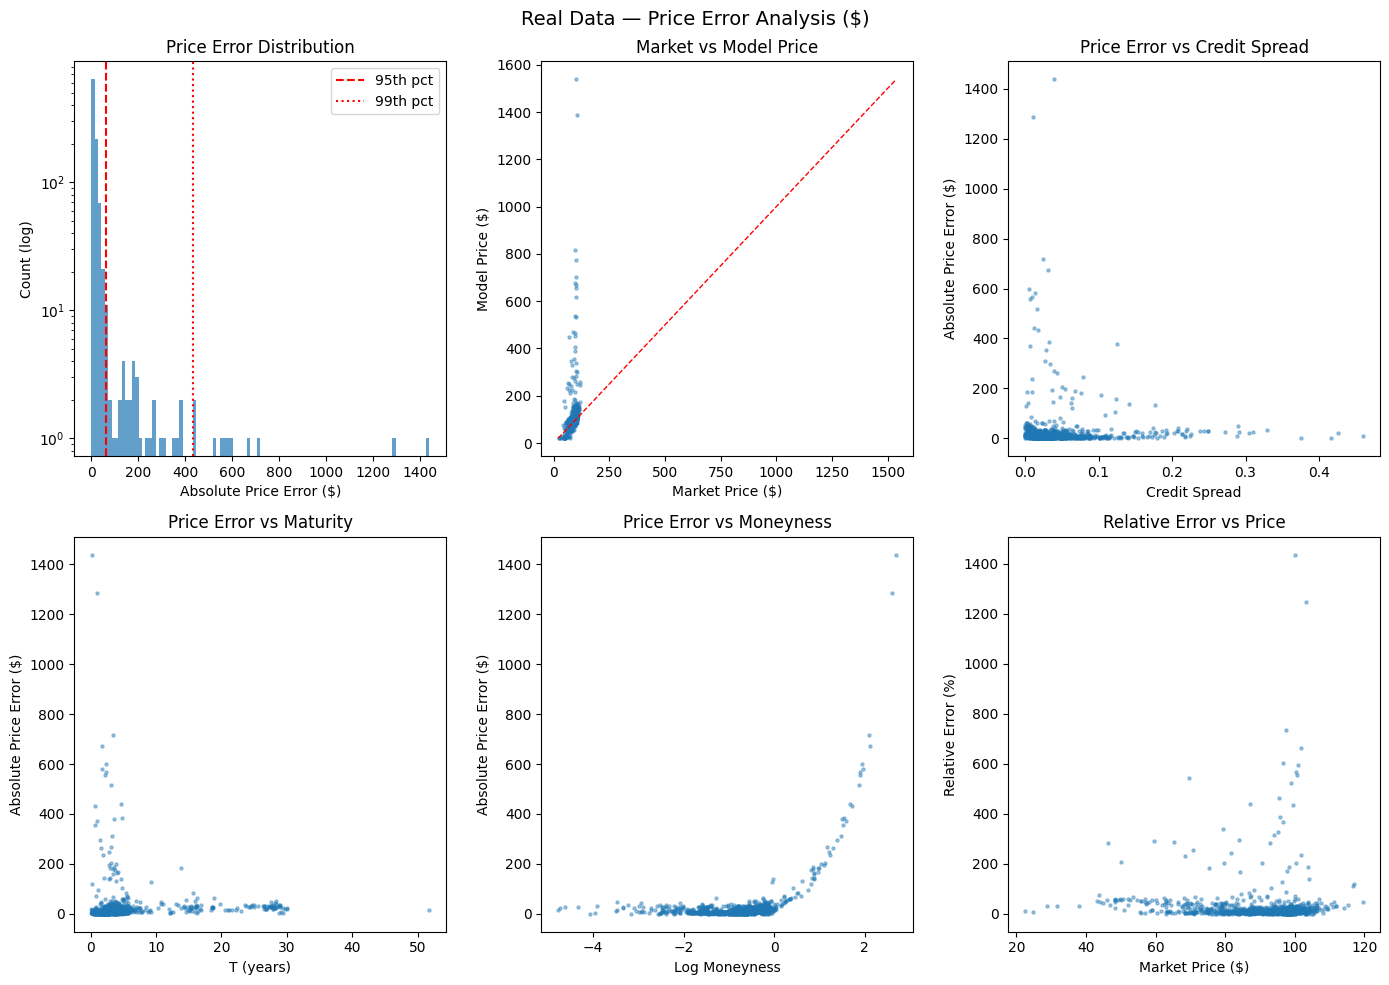

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# 1. Error distribution (log scale)
axes[0, 0].hist(analysis["price_err"], bins=100, edgecolor="none", alpha=0.7)
axes[0, 0].set_yscale("log")
axes[0, 0].set_xlabel("Absolute Price Error ($)")
axes[0, 0].set_ylabel("Count (log)")
axes[0, 0].set_title("Price Error Distribution")
axes[0, 0].axvline(analysis["price_err"].quantile(0.95), color="r", ls="--", label="95th pct")
axes[0, 0].axvline(analysis["price_err"].quantile(0.99), color="r", ls=":", label="99th pct")
axes[0, 0].legend()

# 2. True vs Predicted scatter
axes[0, 1].scatter(analysis["price_true"], analysis["price_pred"], s=5, alpha=0.4)
lims = [min(analysis["price_true"].min(), analysis["price_pred"].min()),
        max(analysis["price_true"].max(), analysis["price_pred"].max())]
axes[0, 1].plot(lims, lims, "r--", lw=1)
axes[0, 1].set_xlabel("Market Price ($)")
axes[0, 1].set_ylabel("Model Price ($)")
axes[0, 1].set_title("Market vs Model Price")

# 3. Error vs maturity
axes[1, 0].scatter(analysis["maturity_years"], analysis["price_err"], s=5, alpha=0.4)
axes[1, 0].set_xlabel("T (years)")
axes[1, 0].set_ylabel("Absolute Price Error ($)")
axes[1, 0].set_title("Price Error vs Maturity")

# 4. Error vs moneyness
axes[1, 1].scatter(analysis["log_moneyness"], analysis["price_err"], s=5, alpha=0.4)
axes[1, 1].set_xlabel("Log Moneyness")
axes[1, 1].set_ylabel("Absolute Price Error ($)")
axes[1, 1].set_title("Price Error vs Moneyness")

# 5. Error vs credit spread
axes[0, 2].scatter(analysis["credit_spread"], analysis["price_err"], s=5, alpha=0.4)
axes[0, 2].set_xlabel("Credit Spread")
axes[0, 2].set_ylabel("Absolute Price Error ($)")
axes[0, 2].set_title("Price Error vs Credit Spread")

# 6. Relative error (%) vs price
axes[1, 2].scatter(analysis["price_true"], analysis["pct_err"], s=5, alpha=0.4)
axes[1, 2].set_xlabel("Market Price ($)")
axes[1, 2].set_ylabel("Relative Error (%)")
axes[1, 2].set_title("Relative Error vs Price")

plt.suptitle("Real Data — Price Error Analysis ($)", fontsize=14)
plt.tight_layout()
plt.show()

## Error Heatmaps

Joint error surfaces across moneyness × maturity and credit spread dimensions.

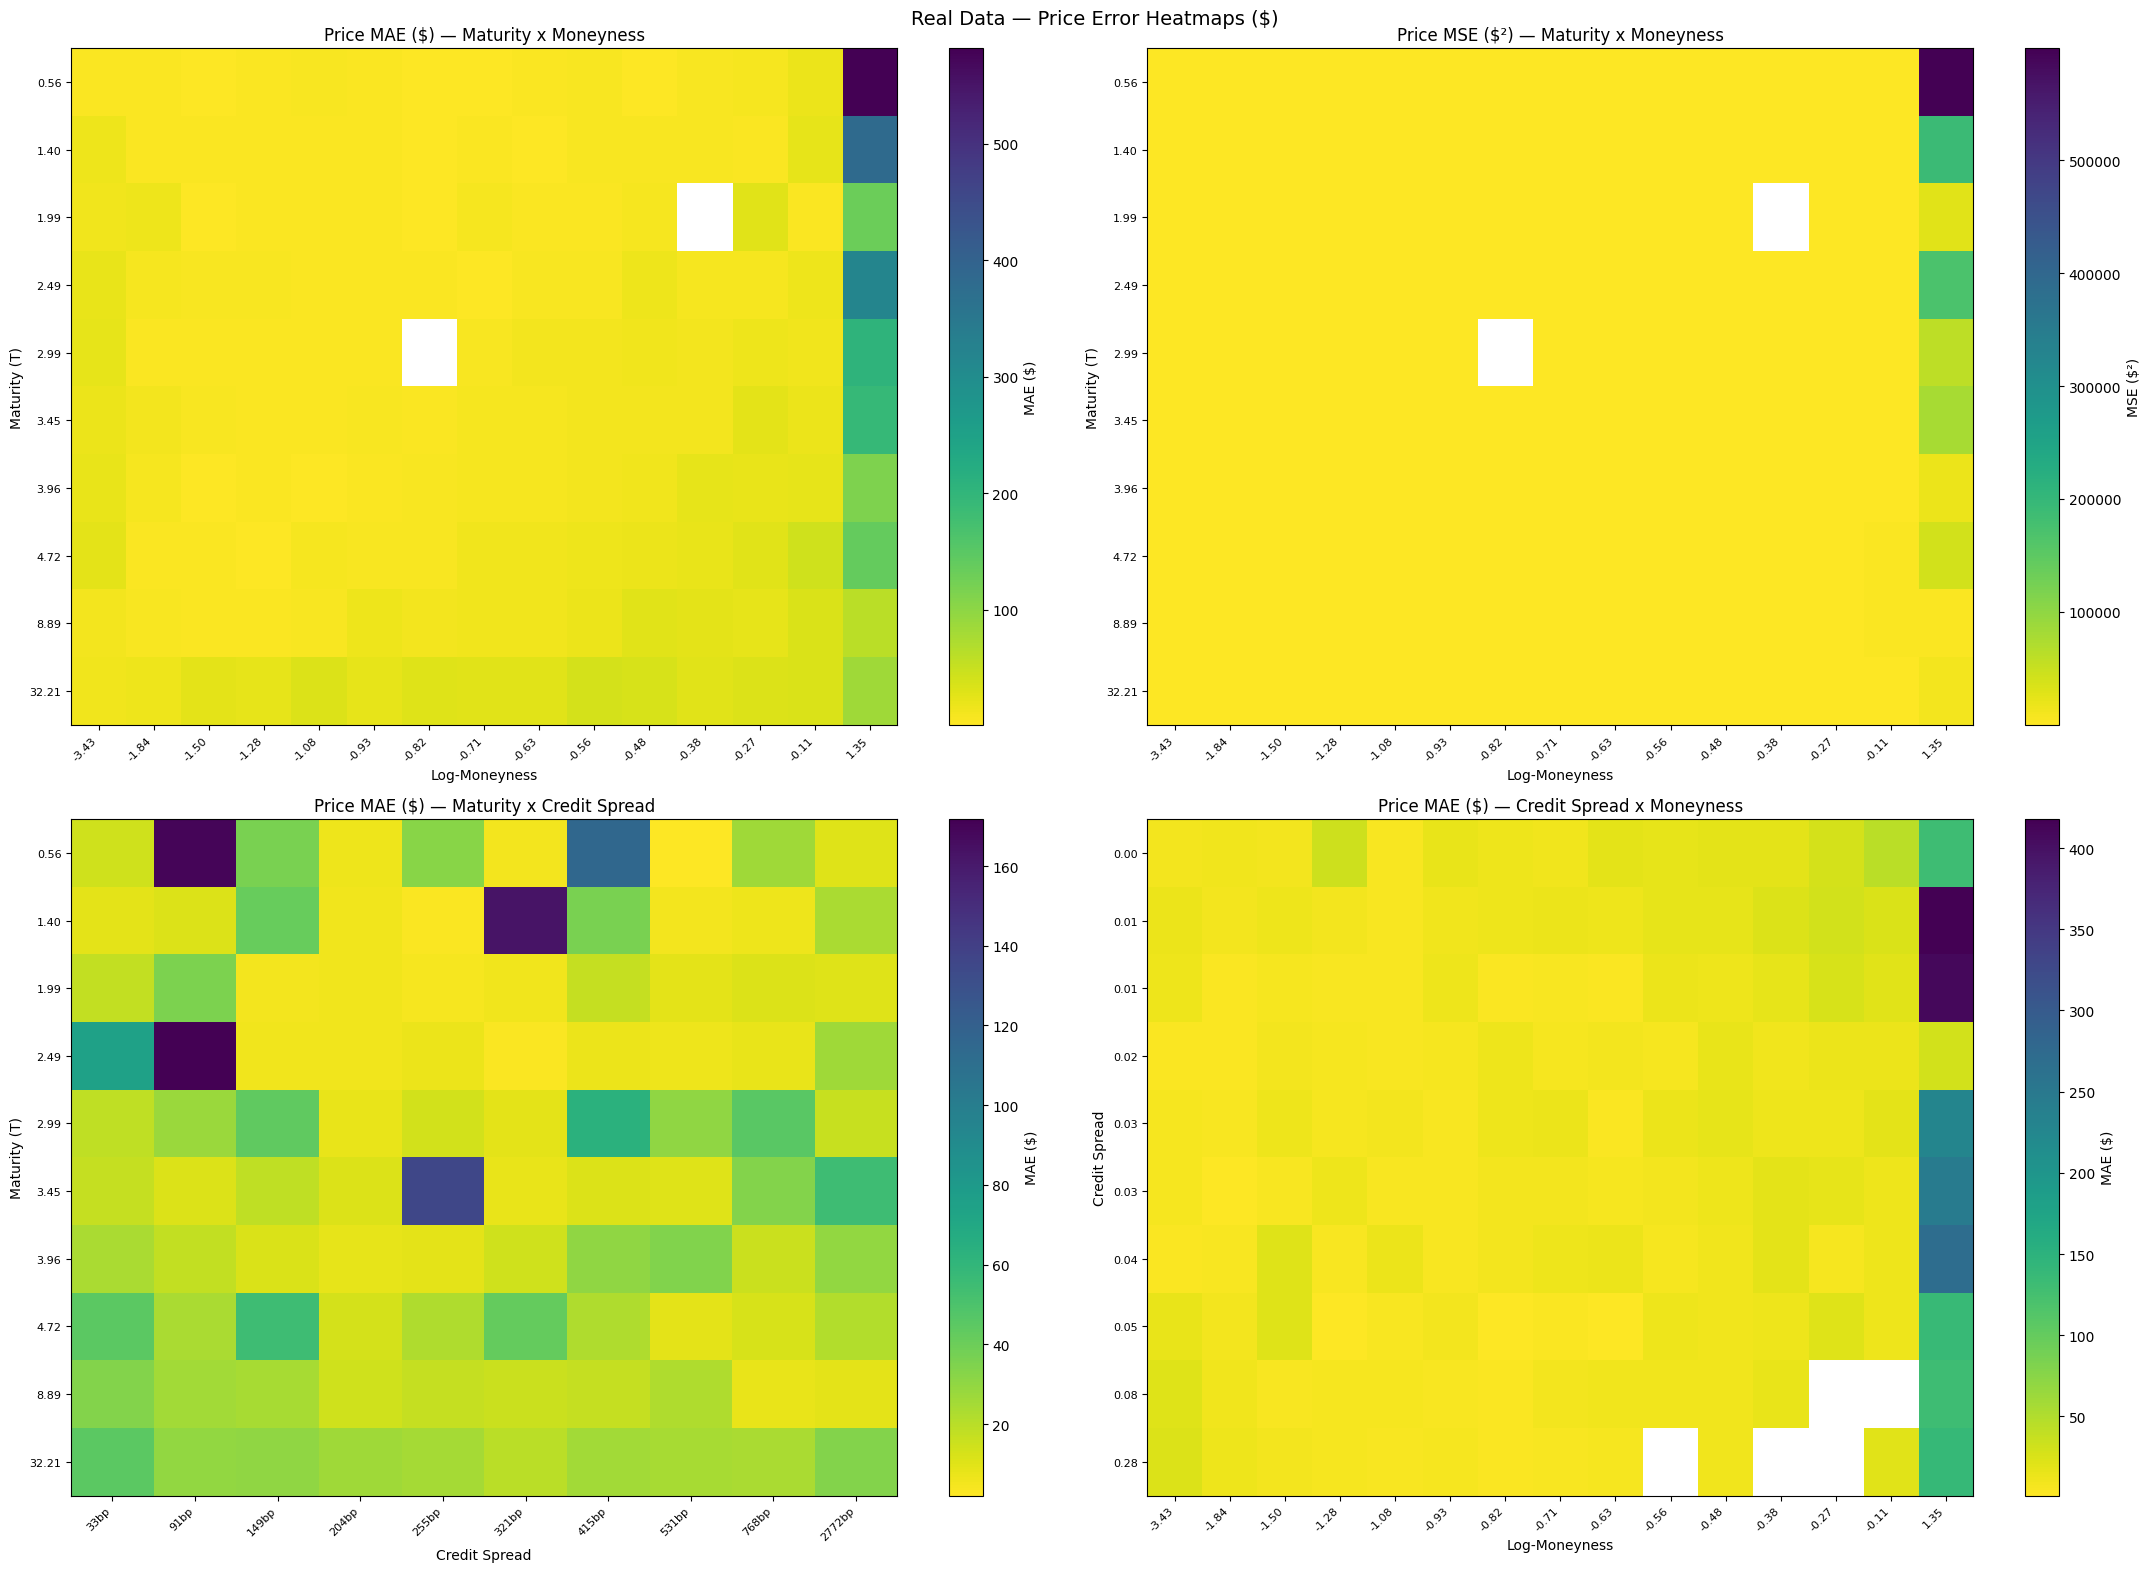

In [10]:
moneyness = analysis["log_moneyness"].values
maturity = analysis["maturity_years"].values
credit = analysis["credit_spread"].values
err_abs = analysis["price_err"].values
err_sq = err_abs ** 2

n_m, n_t, n_c = 15, 10, 10
m_edges = np.percentile(moneyness, np.linspace(0, 100, n_m + 1))
t_edges = np.percentile(maturity, np.linspace(0, 100, n_t + 1))
c_edges = np.percentile(credit, np.linspace(0, 100, n_c + 1))

m_idx = np.clip(np.digitize(moneyness, m_edges[1:-1]), 0, n_m - 1)
t_idx = np.clip(np.digitize(maturity, t_edges[1:-1]), 0, n_t - 1)
c_idx = np.clip(np.digitize(credit, c_edges[1:-1]), 0, n_c - 1)

def build_grid(row_idx, col_idx, n_row, n_col, vals):
    grid = np.full((n_row, n_col), np.nan)
    for ri in range(n_row):
        for ci in range(n_col):
            mask = (row_idx == ri) & (col_idx == ci)
            if mask.sum() > 0:
                grid[ri, ci] = vals[mask].mean()
    return grid

grid_mae_mm = build_grid(t_idx, m_idx, n_t, n_m, err_abs)
grid_mse_mm = build_grid(t_idx, m_idx, n_t, n_m, err_sq)
grid_mae_mc = build_grid(t_idx, c_idx, n_t, n_c, err_abs)
grid_mae_cm = build_grid(c_idx, m_idx, n_c, n_m, err_abs)

m_mids = 0.5 * (m_edges[:-1] + m_edges[1:])
t_mids = 0.5 * (t_edges[:-1] + t_edges[1:])
c_mids = 0.5 * (c_edges[:-1] + c_edges[1:])

fig, axes = plt.subplots(2, 2, figsize=(22, 16))

configs = [
    (axes[0, 0], grid_mae_mm, "Price MAE ($) — Maturity x Moneyness",
     m_mids, t_mids, "Log-Moneyness", "Maturity (T)", "MAE ($)", n_m, n_t, "moneyness"),
    (axes[0, 1], grid_mse_mm, "Price MSE ($²) — Maturity x Moneyness",
     m_mids, t_mids, "Log-Moneyness", "Maturity (T)", "MSE ($²)", n_m, n_t, "moneyness"),
    (axes[1, 0], grid_mae_mc, "Price MAE ($) — Maturity x Credit Spread",
     c_mids, t_mids, "Credit Spread", "Maturity (T)", "MAE ($)", n_c, n_t, "credit"),
    (axes[1, 1], grid_mae_cm, "Price MAE ($) — Credit Spread x Moneyness",
     m_mids, c_mids, "Log-Moneyness", "Credit Spread", "MAE ($)", n_m, n_c, "moneyness"),
]

for ax, grid, title, x_mids, y_mids, xlabel, ylabel, cbar_label, nx, ny, xtype in configs:
    im = ax.imshow(grid, aspect="auto", cmap="viridis_r")
    ax.set_xticks(range(nx))
    if xtype == "credit":
        ax.set_xticklabels([f"{int(v*10000)}bp" for v in x_mids], rotation=45, ha="right", fontsize=8)
    else:
        ax.set_xticklabels([f"{v:.2f}" for v in x_mids], rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(ny))
    ax.set_yticklabels([f"{v:.2f}" for v in y_mids], fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label=cbar_label)

plt.suptitle("Real Data — Price Error Heatmaps ($)", fontsize=14)
plt.tight_layout()
plt.show()

## Gating Distribution

Where the real data lands relative to the variance-optimal moneyness boundary.

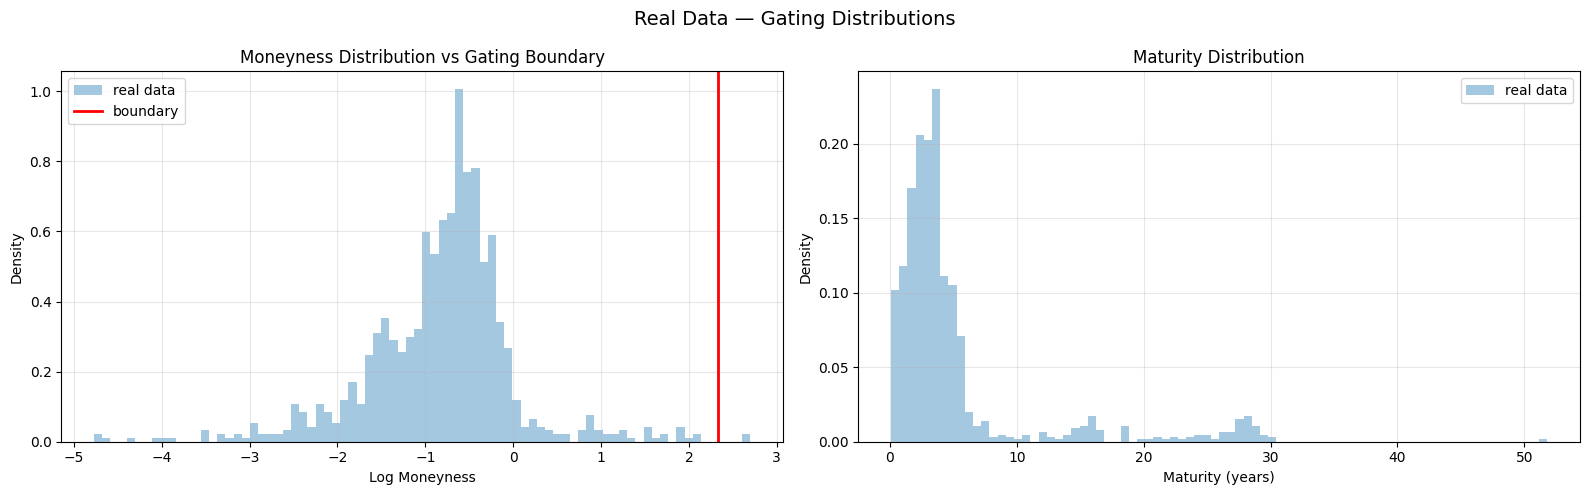

=== Routing Distribution ===
  Expert 0 (OTM, medium-dated): 989 samples (98.9%)
  Expert 1 (ITM, medium-dated): 11 samples (1.1%)


In [11]:
M, N = pricer.gating.M, pricer.gating.N
MONEYNESS_COL = feature_cols.index("log_moneyness")
MATURITY_COL = feature_cols.index("maturity_years")

m_vals = X_raw[:, MONEYNESS_COL].cpu().numpy()
t_vals = X_raw[:, MATURITY_COL].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Moneyness axis
axes[0].hist(m_vals, bins=80, alpha=0.4, density=True, label="real data")
for b in pricer.gating.moneyness_quantiles.tolist():
    axes[0].axvline(b, color="red", ls="-", lw=2, label="boundary")
axes[0].set_xlabel("Log Moneyness")
axes[0].set_ylabel("Density")
axes[0].set_title("Moneyness Distribution vs Gating Boundary")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Maturity axis
axes[1].hist(t_vals, bins=80, alpha=0.4, density=True, label="real data")
for b in pricer.gating.maturity_quantiles.tolist():
    axes[1].axvline(b, color="red", ls="-", lw=2, label="boundary")
axes[1].set_xlabel("Maturity (years)")
axes[1].set_ylabel("Density")
axes[1].set_title("Maturity Distribution")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Real Data — Gating Distributions", fontsize=14)
plt.tight_layout()
plt.show()

# Routing counts
m_bins_np = m_bins.cpu().numpy()
print("=== Routing Distribution ===")
for i in range(M):
    mask = (m_bins_np == i)
    n = mask.sum()
    desc = pricer.gating.describe_cell(i, 0)
    print(f"  Expert {i} ({desc['regime']}): {n:,} samples ({n/len(m_bins_np)*100:.1f}%)")